In [83]:
#%pip install requests
#%pip install --upgrade pymc arviz uncertainties iminuit pytensor
#%pip install pymc arviz uncertainties iminuit scipy pytensor
import os

# Sostituisci con il percorso che hai trovato
compiler_bin_path = r"C:\Users\Andrea\anaconda3\Library\mingw-w64\bin"

# Aggiungi al PATH (all'inizio per sicurezza)
os.environ["PATH"] = compiler_bin_path + os.pathsep + os.environ["PATH"]

# Ora importa PyTensor e verifica
#import pytensor
#print("Compilatore trovato in:", pytensor.config.cxx)
import requests
import os

import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares
from scipy.stats import chi2
import scipy as s
import scipy.stats as sc
from scipy.stats import chi2 as chi2_dist
from scipy.stats import t,norm
plt.rcParams['text.usetex'] = False
try:
    import Uomo_lucertola as lib
    print('Successo Importazione 2')
except ModuleNotFoundError:
    print(f"ERRORE: Impossibile trovare il modulo Uomo_lucertola2. Assicurati che 'Uomo_lucertola2.py' sia nella stessa cartella del notebook: {os.getcwd()}")


import uncertainties
from uncertainties import ufloat, correlated_values
from uncertainties import ufloat
from uncertainties import unumpy
cartella_dati = "misure"

Successo Importazione 2


In [84]:
# Dobbiamo minimizzare la risoluzione energetica R = FWHM / Epeak = 2.355 sigma / Epeak
#Devo fare misure cambiando sia tensione che gain, solo gain e solo tensione

#VALUTAZIONE ERRORE INDOTTO DAL GAIN SULLA TENSIONE
voltaggi_array = np.array([600.2, 650.2, 700.2, 750.2, 800.2, 850.2, 900.2, 950.2, 1000.2, 1050.2, 1100.2])
err_voltaggi = np.full(len(voltaggi_array), 0.2)
voltaggi = unumpy.uarray(voltaggi_array, err_voltaggi)



distanza_misure_gain = ufloat(12, 0.2) #cm

def risoluzione_energetica(sigma, mu):
    return (2.355 * sigma) * mu

#  Gain Variabile

In [85]:
# Lista dei file
file_list = [
    "histo_gain_05.dat",
    "histo_gain_063.dat",
    "histo_gain_089.dat",
    "histo_gain_115.dat",
    "histo_gain_141.dat",
    "histo_gain_167.dat"
]

volt_gain = 700     #[V]
gains = np.array([0.5, 0.63, 0.89, 1.15, 1.41, 1.67]) #Prendiamo 6, 7 misure a 700V
err_gains = np.full(len(gains), 0.1)

'''
for f, g in zip(file_list, gains):
    percorso_completo = os.path.join(cartella_dati, f)
    lib.plot_histogram_from_dat(percorso_completo, title=f"Gain {g}")'''

'\nfor f, g in zip(file_list, gains):\n    percorso_completo = os.path.join(cartella_dati, f)\n    lib.plot_histogram_from_dat(percorso_completo, title=f"Gain {g}")'


  GAIN = 0.5 (Taglio tra 1500 e 1900)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 700V - Gain 0.5
      Area =  5.362e+04 ± 442.4
        mu =       1708 ± 0.3616
     sigma =      63.75 ± 0.4096
   A_fondo =      37.15 ± 45.17
       tau =       1226 ± 2037
         c =     -16.07 ± 83.39
        x0 =       1501 ± 15.01
--------------------------------------------------
Chi2 / ndof = 135.24 / 127 = 1.06
p-value     = 0.2919


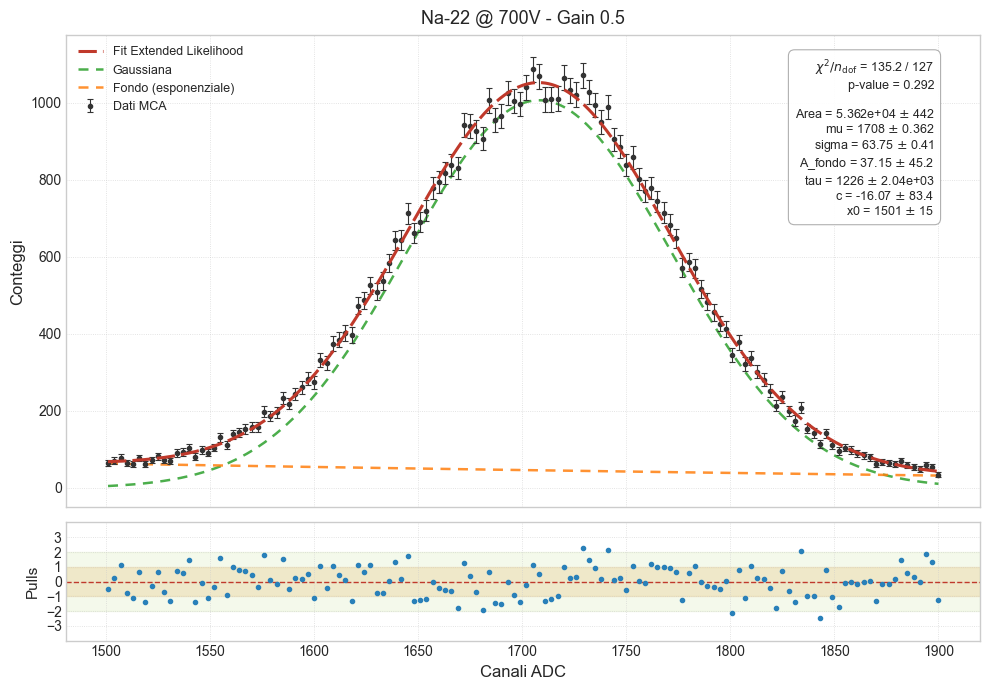

  → Risoluzione R = 0.0879+/-0.0006

  GAIN = 0.63 (Taglio tra 1500 e 1950)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 700V - Gain 0.63
      Area =  6.058e+04 ± 397
        mu =       1729 ± 0.2993
     sigma =      60.79 ± 0.3175
   A_fondo =      29.05 ± 22.1
       tau =      702.7 ± 702.7
         c =     -4.197 ± 22.38
        x0 =       1501 ± 15.01
--------------------------------------------------
Chi2 / ndof = 181.55 / 143 = 1.27
p-value     = 0.01616


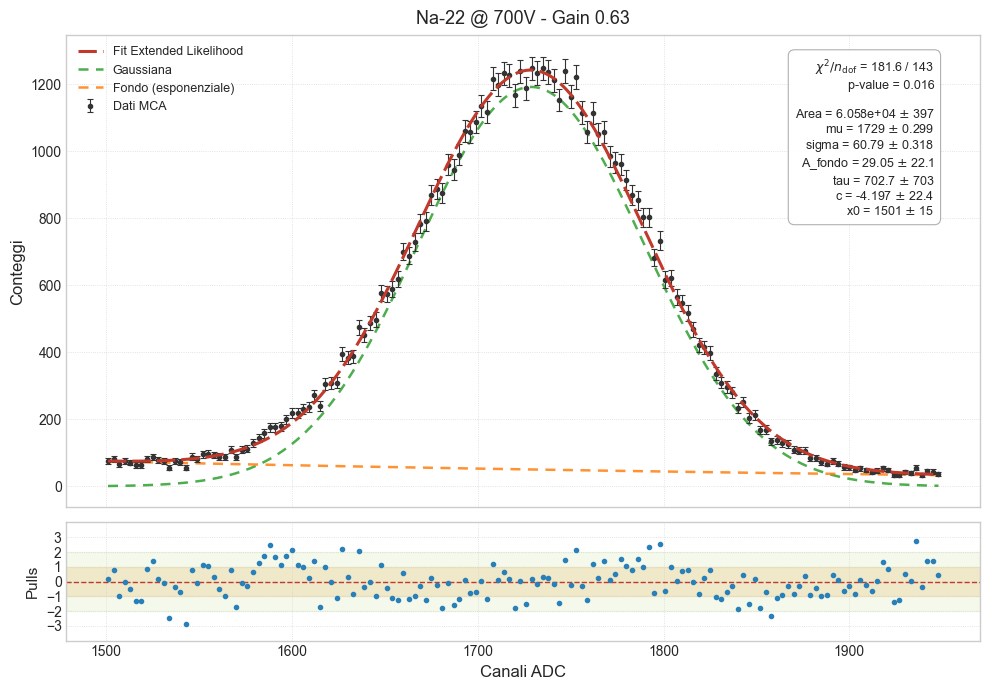

  → Risoluzione R = 0.0828+/-0.0004

  GAIN = 0.89 (Taglio tra 1950 e 2600)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 700V - Gain 0.89
      Area =  5.214e+04 ± 271.3
        mu =       2280 ± 0.4226
     sigma =      81.69 ± 0.3852
   A_fondo =      152.3 ± 42.04
       tau =  1.187e+04 ± 3371
         c =     -137.6 ± 42
        x0 =       1951 ± 19.51
--------------------------------------------------
Chi2 / ndof = 260.17 / 210 = 1.24
p-value     = 0.01049


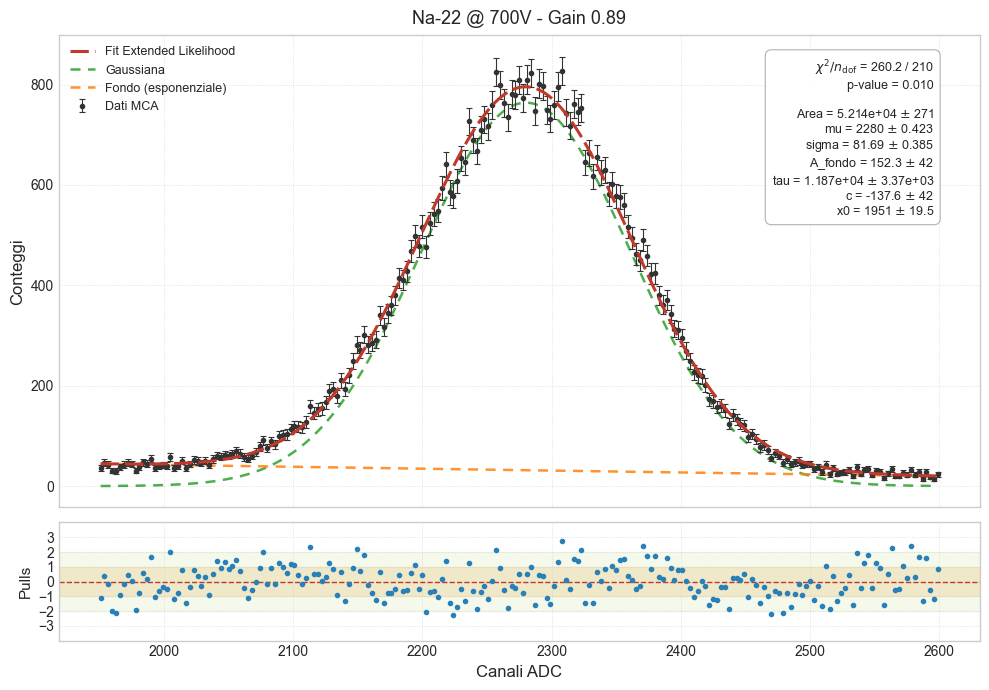

  → Risoluzione R = 0.0844+/-0.0004

  GAIN = 1.15 (Taglio tra 3000 e 3900)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 700V - Gain 1.15
      Area =  7.137e+04 ± 374.5
        mu =       3498 ± 0.591
     sigma =      128.4 ± 0.6075
   A_fondo =      21.64 ± 6.049
       tau =       1674 ± 629.4
         c =     -7.687 ± 6.09
        x0 =       3001 ± 30.01
--------------------------------------------------
Chi2 / ndof = 311.91 / 293 = 1.06
p-value     = 0.2141


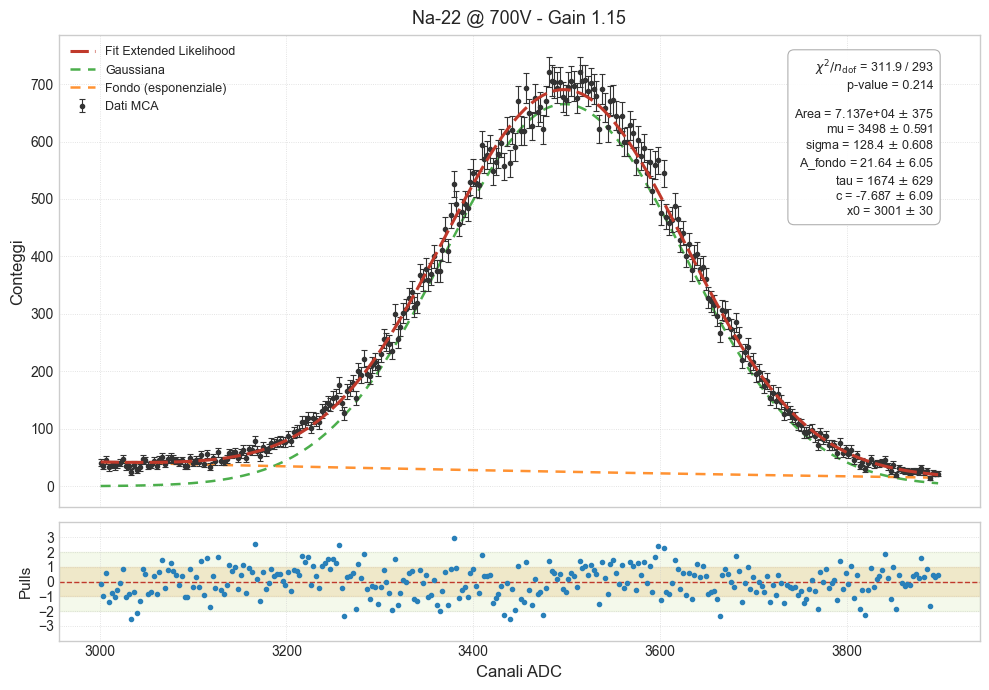

  → Risoluzione R = 0.0865+/-0.0004

  GAIN = 1.41 (Taglio tra 3600 e 4650)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 700V - Gain 1.41
      Area =  6.097e+04 ± 451
        mu =       4047 ± 0.7653
     sigma =      144.6 ± 0.8039
   A_fondo =      7.692 ± 0.7393
       tau =      393.5 ± 132.5
         c =      4.298 ± 0.6094
        x0 =       3601 ± 36.01
--------------------------------------------------
Chi2 / ndof = 425.05 / 343 = 1.24
p-value     = 0.001652


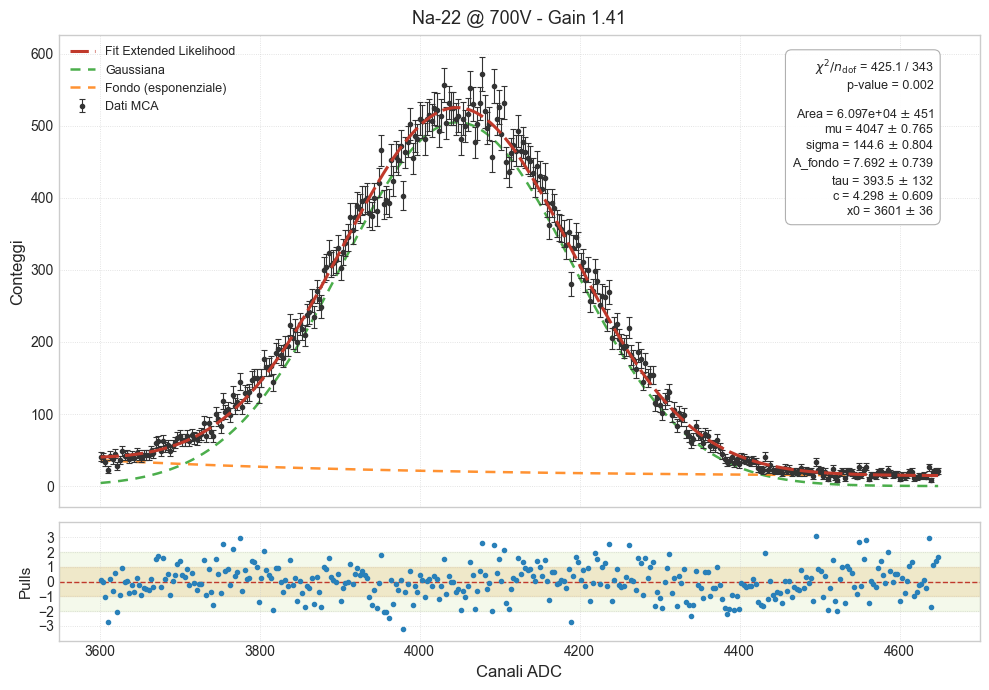

  → Risoluzione R = 0.0841+/-0.0005

  GAIN = 1.67 (Taglio tra 4500 e 5500)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 700V - Gain 1.67
      Area =  6.044e+04 ± 2
        mu =       5067 ± 0.7831
     sigma =      182.9 ± 0.7741
   A_fondo =       1457 ± 1.271
       tau =  2.591e+05 ± 2
         c =      -1448 ± 1.265
        x0 =       4501 ± 45.01
--------------------------------------------------
Chi2 / ndof = 364.05 / 327 = 1.11
p-value     = 0.07734


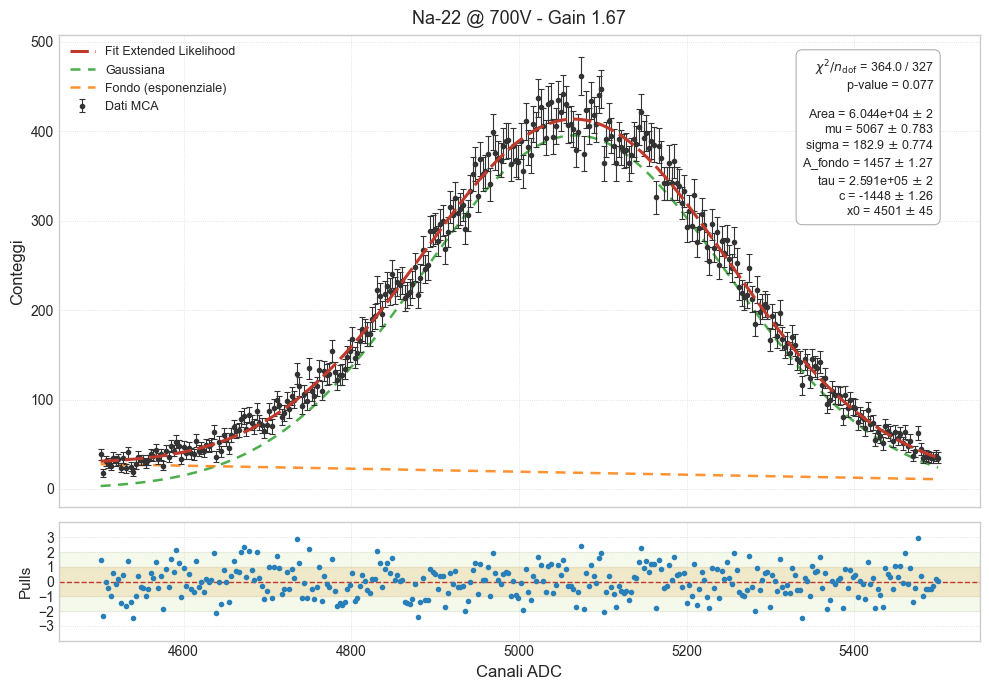

  → Risoluzione R = 0.0850+/-0.0004


In [99]:
ch_max_array = np.array([1900, 1950, 2600, 3900, 4650, 5500])
ch_min_array = np.array([1500, 1500, 1950, 3000, 3600, 4500])

risultati = []

# 2. Usa zip per accoppiare file, gain e i limiti giusti in un colpo solo!
for filename, gain, c_min, c_max in zip(file_list, gains, ch_min_array, ch_max_array):
    print(f"\n{'='*60}")
    print(f"  GAIN = {gain} (Taglio tra {c_min} e {c_max})")
    print(f"{'='*60}")
    
    percorso_completo = os.path.join(cartella_dati, filename)
    canali, conteggi = lib.estrai_spettro(percorso_completo, show_plot=False)
    canali, conteggi = lib.rebin(canali, conteggi, n=3)

    # 3. Ora c_min e c_max sono numeri singoli esatti per questo specifico file
    mask = (canali >= c_min) & (canali <= c_max)
    x_picco = canali[mask]
    y_picco = conteggi[mask]
    
    # Stime iniziali
    mu_guess = x_picco[np.argmax(y_picco)]
    area_guess = np.sum(y_picco)
    fondo_guess = np.mean(y_picco[:5])
    sigma_guess = 15
    x0_guess = x_picco[0]
    c_guess = np.mean(y_picco[-5:])
    if c_guess <= 0: c_guess = 1.0

    # 3. Stima dell'altezza dell'esponenziale 'A_fondo' (coda sinistra)
    sinistra_mean = np.mean(y_picco[:5])
    A_fondo_guess = sinistra_mean - c_guess
    if A_fondo_guess <= 0: A_fondo_guess = 10.0 # Sicurezza

    # 4. Stima di 'tau' (un terzo della finestra)
    tau_guess = (x_picco[-1] - x_picco[0]) / 3.0

    # 5. Stime del picco (mu e sigma)
    mu_guess = x_picco[np.argmax(y_picco)]
    sigma_guess = 15.0 # Per i NaI di solito è un valore iniziale eccellente

    # 6. Stima dell'Area (Totale - Area del fondo a trapezio)
    fondo_medio = (sinistra_mean + c_guess) / 2.0
    area_guess = np.sum(y_picco) - (fondo_medio * len(x_picco))
    if area_guess <= 0: area_guess = np.sum(y_picco) * 0.5
    
    # 4. Corretti i parametri per la parabola (a, b, c)
    parametri_iniziali = {
        'Area': area_guess, 
        'mu': mu_guess, 
        'sigma': sigma_guess, 
        'A_fondo': A_fondo_guess,
        'tau': tau_guess,
        'c': fondo_guess,
        'x0': x0_guess
    }
    
    # 5. Corretti gli assegnamenti di CDF e PDF
    fit = lib.FitLikelihoodBomberone(
        canali=x_picco,
        conteggi=y_picco,
        modello_cdf = lib.picco_esponenziale_cdf,
        modello_pdf = lib.picco_esponenziale_pdf,
        initial_params=parametri_iniziali,
        title=f"Na-22 @ 700V - Gain {gain}"
    )
    
    fit.perform_fit()
    fit.plot_results(componenti=[('Gaussiana', lib.funzione_gaussiana_pdf), ('Fondo (esponenziale)', lib.funzione_esponenziale_pdf)])  
    
    # 6. Calcolo risoluzione
    if fit.is_fit_valid:
        mu  = ufloat(fit.fit_result['mu'][0], fit.fit_result['mu'][1])
        sig = ufloat(fit.fit_result['sigma'][0], fit.fit_result['sigma'][1])
        
        R = 2.355 * sig / mu
        risultati.append((gain, mu, sig, R))
        print(f"  → Risoluzione R = {R:.4f}")
    else:
        print(f"  ⚠️ Fit non valido per gain {gain}")
        risultati.append((gain, None, None, None))

In [87]:
# Filtra solo i risultati validi
risultati_validi = [(g, mu, sig, R) for g, mu, sig, R in risultati if R is not None]

# 1. Calcolo della R media pesata
R_nominali = np.array([r[3].nominal_value for r in risultati_validi])
R_errori   = np.array([r[3].std_dev for r in risultati_validi])

for R, err_r in zip(R_nominali, R_errori):
    print(f"R dai fit = {R*100:.6f} ± {err_r*100:.6f}")


# Media pesata: w_i = 1/sigma_i^2
pesi = 1.0 / R_errori**2
R_media    = np.sum(pesi * R_nominali) / np.sum(pesi)
R_media_err = 1.0 / np.sqrt(np.sum(pesi))

print(f"R media pesata = {R_media:.6f} ± {R_media_err:.6f}")
print(f"R media pesata = {R_media*100:.3f}% ± {R_media_err*100:.3f}%")
'''
# 2. Test di compatibilità per ogni gain
print("\n" + "="*60)
print("  TEST DI COMPATIBILITÀ: R_singola vs R_media")
print("="*60)

for gain, mu, sig, R in risultati_validi:
    lib.test_compatibilita(
        R.nominal_value, R_media,
        R.std_dev, R_media_err,
        val1_name=f"R(gain={gain})",
        val2_name="R_media"
    )'''


R dai fit = 8.784837 ± 0.054709
R dai fit = 8.288789 ± 0.041903
R dai fit = 8.437754 ± 0.039663
R dai fit = 8.635893 ± 0.040800
R dai fit = 8.411752 ± 0.046764
R dai fit = 8.504747 ± 0.055705
R media pesata = 0.084925 ± 0.000185
R media pesata = 8.493% ± 0.019%


'\n# 2. Test di compatibilità per ogni gain\nprint("\n" + "="*60)\nprint("  TEST DI COMPATIBILITÀ: R_singola vs R_media")\nprint("="*60)\n\nfor gain, mu, sig, R in risultati_validi:\n    lib.test_compatibilita(\n        R.nominal_value, R_media,\n        R.std_dev, R_media_err,\n        val1_name=f"R(gain={gain})",\n        val2_name="R_media"\n    )'

In [88]:
#Il chi2 globale è meglio dei test singoli perchè diminuisco la possibilità di un falso positivo e perchè accumula l'informazione globale 

chi2_compat = np.sum(((R_nominali - R_media) / R_errori)**2)
ndof = len(R_nominali) - 1  # -1 perché hai stimato la media
p_val = 1 - sc.chi2.cdf(chi2_compat, ndof)

print(f"\nChi2 di compatibilità globale: {chi2_compat:.2f} / {ndof} ndof")
print(f"p-value = {p_val:.4f}")
if p_val > 0.05:
    print("→ Le R sono TUTTE compatibili tra loro: il gain NON influisce.")
else:
    print("→ Le R NON sono tutte compatibili: il gain INFLUISCE.")



Chi2 di compatibilità globale: 69.47 / 5 ndof
p-value = 0.0000
→ Le R NON sono tutte compatibili: il gain INFLUISCE.


#  Variando la finestra

In [89]:
import itertools

Delta = 80  #canali di variazione sulla finestra

risultati_con_sist = []

for filename, gain, c_min, c_max in zip(file_list, gains, ch_min_array, ch_max_array):
    R_variazioni = []
    
    variazioni = [-Delta, 0, Delta]
    
    for d_min, d_max in itertools.product(variazioni, repeat=2):
        c_min_var = c_min + d_min
        c_max_var = c_max + d_max
        
        percorso_completo = os.path.join(cartella_dati, filename)
        canali, conteggi = lib.estrai_spettro(percorso_completo, show_plot=False)
        canali, conteggi = lib.rebin(canali, conteggi, n=4)
        mask = (canali >= c_min_var) & (canali <= c_max_var)
        x_p = canali[mask]
        y_p = conteggi[mask]
        
        if len(x_p) < 30:
            continue
        

        # 3. Ora c_min e c_max sono numeri singoli esatti per questo specifico file
        mask = (canali >= c_min) & (canali <= c_max)
        x_picco = canali[mask]
        y_picco = conteggi[mask]
    
        # Stime iniziali
        mu_guess = x_picco[np.argmax(y_picco)]
        area_guess = np.sum(y_picco)
        fondo_guess = np.mean(y_picco[:5])
        sigma_guess = 15
        x0_guess = x_picco[0]
        c_guess = np.mean(y_picco[-5:])
        if c_guess <= 0: c_guess = 1.0

        # 3. Stima dell'altezza dell'esponenziale 'A_fondo' (coda sinistra)
        sinistra_mean = np.mean(y_picco[:5])
        A_fondo_guess = sinistra_mean - c_guess
        if A_fondo_guess <= 0: A_fondo_guess = 10.0 # Sicurezza

        # 4. Stima di 'tau' (un terzo della finestra)
        tau_guess = (x_picco[-1] - x_picco[0]) / 3.0

        # 5. Stime del picco (mu e sigma)
        mu_guess = x_picco[np.argmax(y_picco)]
        sigma_guess = 15.0 # Per i NaI di solito è un valore iniziale eccellente

        # 6. Stima dell'Area (Totale - Area del fondo a trapezio)
        fondo_medio = (sinistra_mean + c_guess) / 2.0
        area_guess = np.sum(y_picco) - (fondo_medio * len(x_picco))
        if area_guess <= 0: area_guess = np.sum(y_picco) * 0.5
    
        params = {
        'Area': area_guess, 
        'mu': mu_guess, 
        'sigma': sigma_guess, 
        'A_fondo': A_fondo_guess,
        'tau': tau_guess,
        'c': fondo_guess,
        'x0': x0_guess
        }

        fit = lib.FitLikelihoodBomberone(
            canali=x_p, conteggi=y_p,
            modello_cdf=lib.picco_esponenziale_cdf,
            modello_pdf=lib.picco_esponenziale_pdf,
            initial_params=params,
            title=f"Variazione gain {gain}"
        )
        fit.perform_fit()
        
        if fit.is_fit_valid:
            R_var = 2.355 * fit.fit_result['sigma'][0] / fit.fit_result['mu'][0]
            R_variazioni.append(R_var)
    
    sigma_sist = np.std(R_variazioni) if len(R_variazioni) > 1 else 0.0
    risultati_con_sist.append((gain, sigma_sist))
    print(f"Gain {gain}: {len(R_variazioni)} fit validi → σ_sist = {sigma_sist:.6f}")


 RISULTATI FIT LIKELIHOOD: Variazione gain 0.5
      Area =  5.422e+04 ± 2
        mu =       1708 ± 0.3481
     sigma =      64.68 ± 0.3196
   A_fondo =       2131 ± 1.372
       tau =  9.711e+04 ± 2
         c =      -2112 ± 1.368
        x0 =       1502 ± 15.02
--------------------------------------------------
Chi2 / ndof = 119.88 / 93 = 1.29
p-value     = 0.03174
 RISULTATI FIT LIKELIHOOD: Variazione gain 0.5
      Area =  5.385e+04 ± 289.9
        mu =       1708 ± 0.3112
     sigma =      64.06 ± 0.3148
   A_fondo =       2485 ± 5.083
       tau =  1.212e+05 ± 2320
         c =      -2466 ± 5.082
        x0 =       1502 ± 15.02
--------------------------------------------------
Chi2 / ndof = 143.27 / 113 = 1.27
p-value     = 0.02867
 RISULTATI FIT LIKELIHOOD: Variazione gain 0.5
      Area =  5.341e+04 ± 326.9
        mu =       1707 ± 0.3241
     sigma =      63.51 ± 0.3255
   A_fondo =      12.71 ± 10.78
       tau =      693.3 ± 693.3
         c =      6.446 ± 10.6
        x0

In [90]:
# Ricalcolo R_media con errori totali
R_tot_nominali = np.array([r[3].nominal_value for r in risultati_validi])
diz_sist_gain = dict(risultati_con_sist)  # fix: indentazione corretta
R_tot_errori = np.array([                 # fix: assegnazione + sintassi list comprehension
    np.sqrt(r[3].std_dev**2 + diz_sist_gain[r[0]]**2)
    for i, r in enumerate(risultati_validi)  # fix: aggiunto ':'... no, è dentro []
])
pesi_tot = 1.0 / R_tot_errori**2
R_media_tot = np.sum(pesi_tot * R_tot_nominali) / np.sum(pesi_tot)
R_media_tot_err = 1.0 / np.sqrt(np.sum(pesi_tot))

print(f"R media pesata (con sist) = {R_media_tot:.6f} ± {R_media_tot_err:.6f}")
print(f"R media pesata (con sist) = {R_media_tot*100:.3f}% ± {R_media_tot_err*100:.3f}%")
'''
print("\n" + "="*60)
print("  TEST DI COMPATIBILITÀ CON ERRORE SISTEMATICO")
print("="*60)

for i, (gain, mu, sig, R) in enumerate(risultati_validi):
    sigma_tot = R_tot_errori[i]
    print(f"\n  [σ_stat={R.std_dev:.5f}, σ_sist={diz_sist_gain[gain]:.5f}, σ_tot={sigma_tot:.5f}]")
    lib.test_compatibilita(
        R.nominal_value, R_media_tot,
        sigma_tot, R_media_tot_err,
        val1_name=f"R(gain={gain})",
        val2_name="R_media"
    )'''

# Chi2 globale con errori totali
chi2_compat_tot = np.sum(((R_tot_nominali - R_media_tot) / R_tot_errori)**2)
ndof_tot = len(R_tot_nominali) - 1
p_val_tot = 1 - sc.chi2.cdf(chi2_compat_tot, ndof_tot)

print(f"\nChi2 globale (con sist): {chi2_compat_tot:.2f} / {ndof_tot} ndof")
print(f"p-value = {p_val_tot:.4f}")
if p_val_tot > 0.05:
    print("→ Le R sono COMPATIBILI (includendo l'errore sistematico).")
else:
    print("→ Le R NON sono compatibili anche con l'errore sistematico.")


R media pesata (con sist) = 0.084850 ± 0.000369
R media pesata (con sist) = 8.485% ± 0.037%

Chi2 globale (con sist): 10.84 / 5 ndof
p-value = 0.0546
→ Le R sono COMPATIBILI (includendo l'errore sistematico).


#  Misure con Volt diversi, gain uguale, per Vbias


#  Aggiungendo le ultime tensioni

In [91]:
file_volt_list2 = [
    #"histo_tensione_500.dat",
    "histo_tensione_550.dat",
    "histo_tensione_600.dat",
    "histo_tensione_650.dat",
    "histo_tensione_675.dat",
    "histo_tensione_700.dat",
    "histo_tensione_725.dat",
    "histo_tensione_750.dat",
    "histo_tensione_775.dat",
    "histo_tensione_800.dat",
    "histo_tensione_825.dat",
    "histo_tensione_850.dat"
]


In [92]:
file_volt_list_strana_histo = [
    "histo_tensione_500.dat",
    "histo_tensione_550.dat",
    "histo_tensione_600.dat"
]

voltaggis = np.array([500, 550, 600])
'''
for f, v in zip(file_volt_list_strana_histo, voltaggis):
    lib.plot_histogram_from_dat(f, title=f"Volt {v}")'''

'\nfor f, v in zip(file_volt_list_strana_histo, voltaggis):\n    lib.plot_histogram_from_dat(f, title=f"Volt {v}")'


  VOLTAGGIO = 550 (Taglio tra 1800 e 2400)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 550V
      Area =  3.989e+04 ± 324
        mu =       2046 ± 0.4586
     sigma =      73.42 ± 0.4721
   A_fondo =      8.745 ± 0.8599
       tau =      203.4 ± 76.01
         c =      6.486 ± 0.6948
        x0 =       1801 ± 18.01
--------------------------------------------------
Chi2 / ndof = 224.36 / 193 = 1.16
p-value     = 0.06048


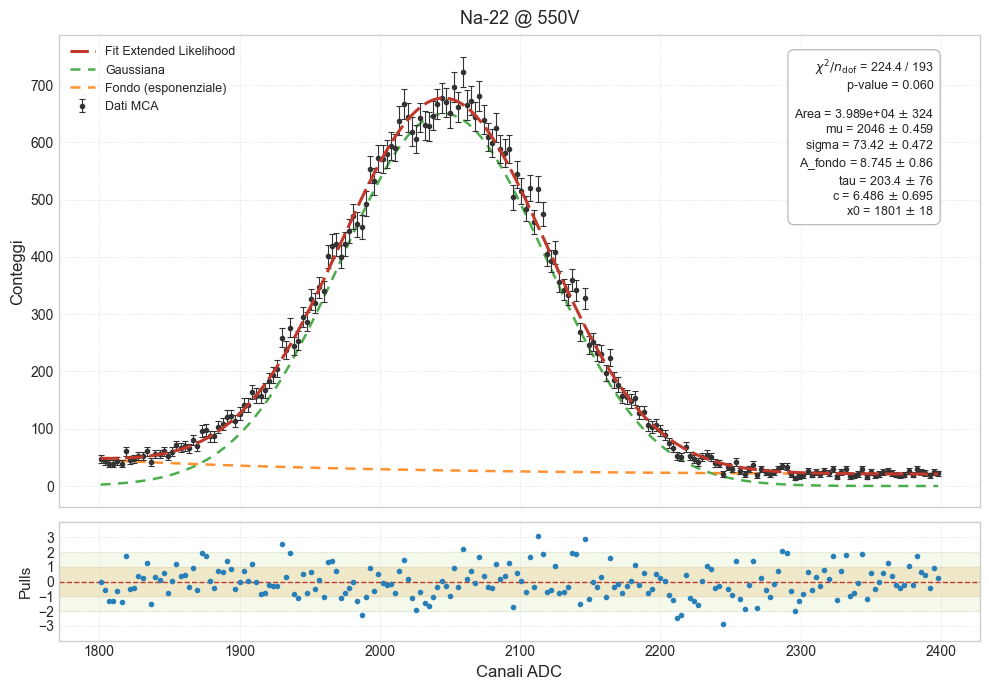

  → Risoluzione R = 0.0845+/-0.0005

  VOLTAGGIO = 600 (Taglio tra 1800 e 2400)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 600V
      Area =   2.56e+04 ± 265.6
        mu =       2091 ± 0.5836
     sigma =      77.02 ± 0.6252
   A_fondo =      5.162 ± 1.978
       tau =      387.3 ± 371.4
         c =      3.173 ± 2.148
        x0 =       1801 ± 18.01
--------------------------------------------------
Chi2 / ndof = 203.77 / 193 = 1.06
p-value     = 0.2836


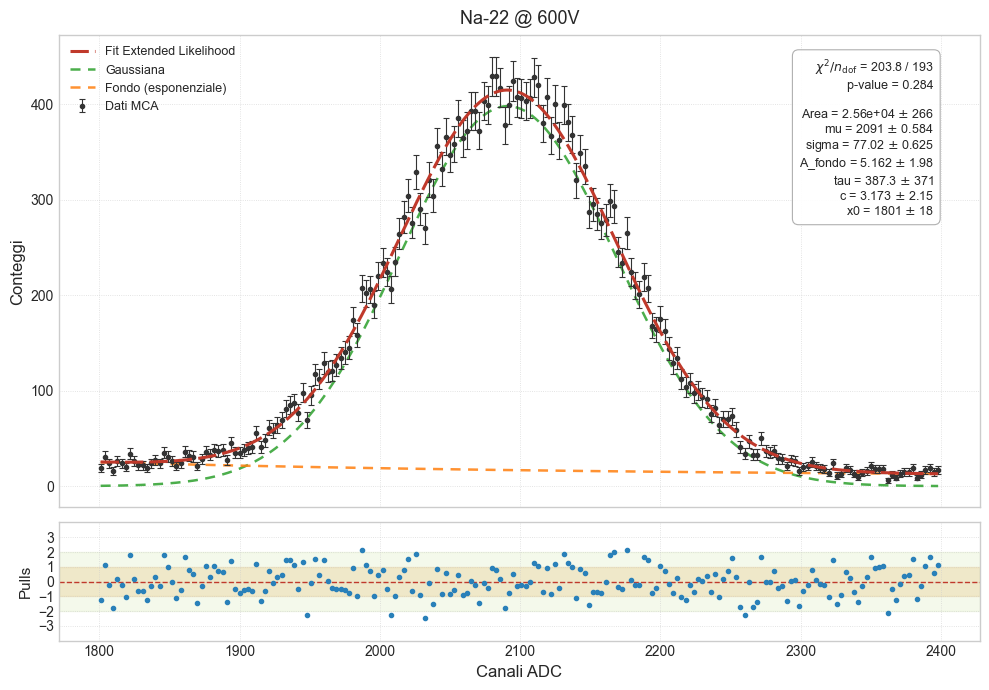

  → Risoluzione R = 0.0867+/-0.0007

  VOLTAGGIO = 650 (Taglio tra 700 e 1000)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 650V
      Area =  5.636e+04 ± 275.5
        mu =      906.2 ± 0.149
     sigma =      31.63 ± 0.1336
   A_fondo =       8575 ± 17.71
       tau =   8.49e+04 ± 1091
         c =      -8526 ± 17.63
        x0 =        700 ± 7
--------------------------------------------------
Chi2 / ndof = 128.95 / 94 = 1.37
p-value     = 0.009773


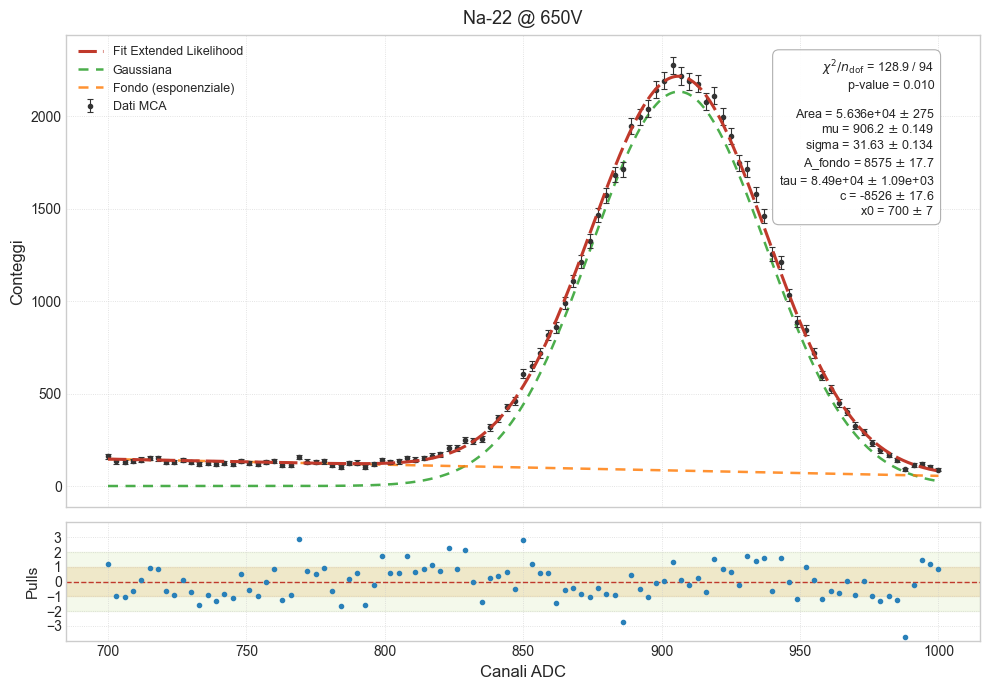

  → Risoluzione R = 0.0822+/-0.0003

  VOLTAGGIO = 675 (Taglio tra 1000 e 1400)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 675V
      Area =  5.842e+04 ± 272.3
        mu =       1213 ± 0.195
     sigma =      41.98 ± 0.1715
   A_fondo =       6198 ± 14.13
       tau =   1.33e+05 ± 1085
         c =      -6163 ± 14.08
        x0 =       1000 ± 10
--------------------------------------------------
Chi2 / ndof = 214.57 / 127 = 1.69
p-value     = 1.931e-06


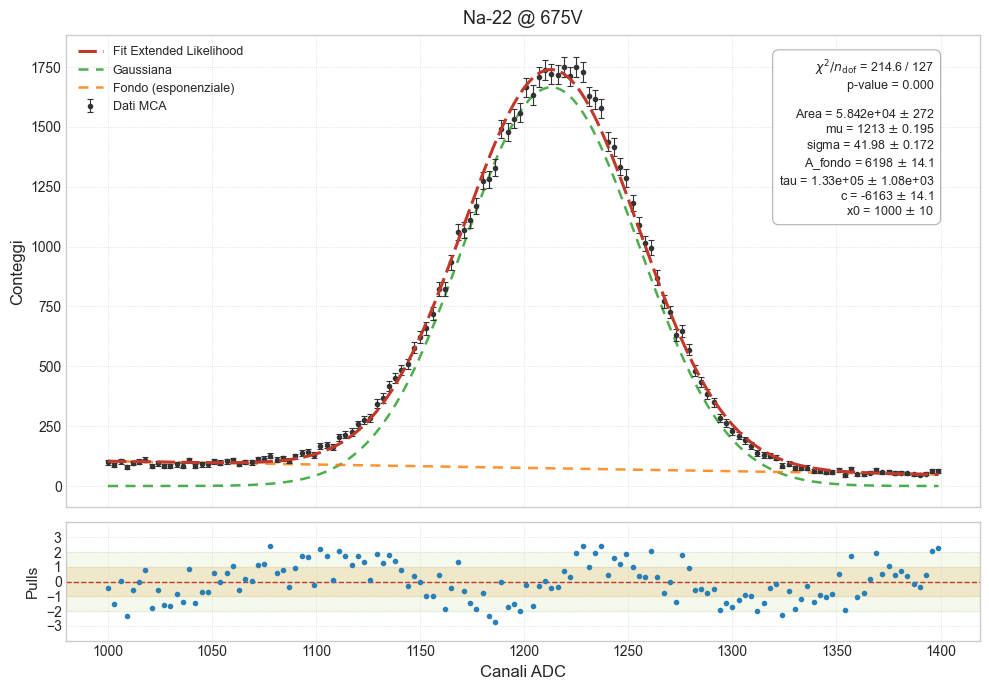

  → Risoluzione R = 0.0815+/-0.0003

  VOLTAGGIO = 700 (Taglio tra 1400 e 1800)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 700V
      Area =  5.282e+04 ± 300.3
        mu =       1618 ± 0.2771
     sigma =      56.71 ± 0.2885
   A_fondo =       4624 ± 12.77
       tau =   1.49e+05 ± 1871
         c =      -4602 ± 12.78
        x0 =       1402 ± 14.02
--------------------------------------------------
Chi2 / ndof = 153.66 / 126 = 1.22
p-value     = 0.04744


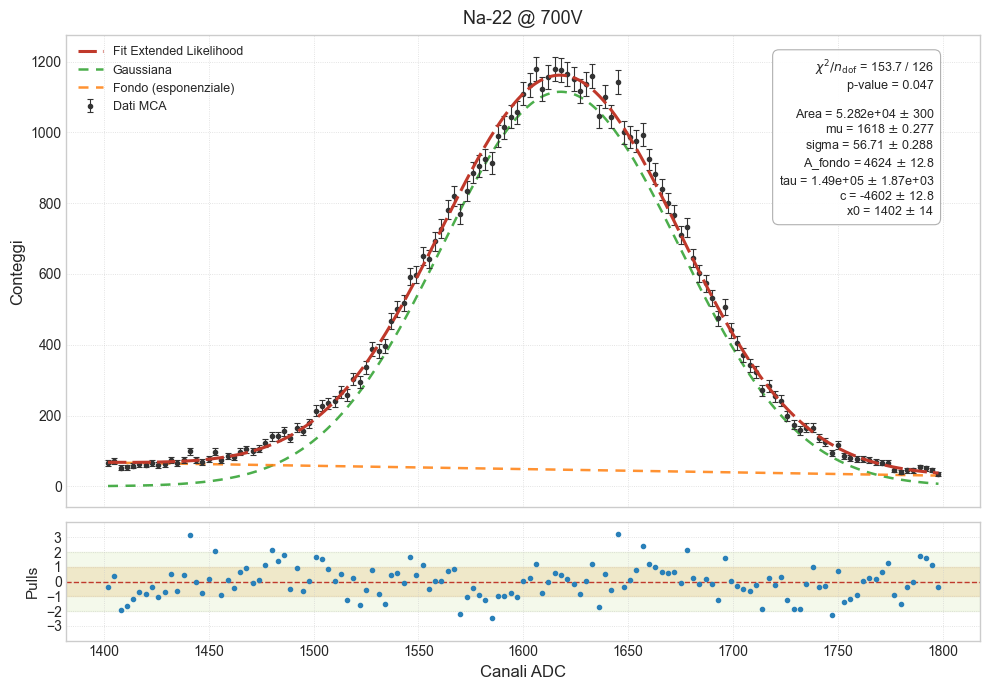

  → Risoluzione R = 0.0825+/-0.0004

  VOLTAGGIO = 725 (Taglio tra 1850 e 2400)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 725V
      Area =  5.297e+04 ± 2
        mu =       2137 ± 0.3581
     sigma =      74.35 ± 0.3382
   A_fondo =       1617 ± 1.465
       tau =  8.611e+04 ± 2
         c =      -1599 ± 1.467
        x0 =       1852 ± 18.52
--------------------------------------------------
Chi2 / ndof = 215.21 / 176 = 1.22
p-value     = 0.02345


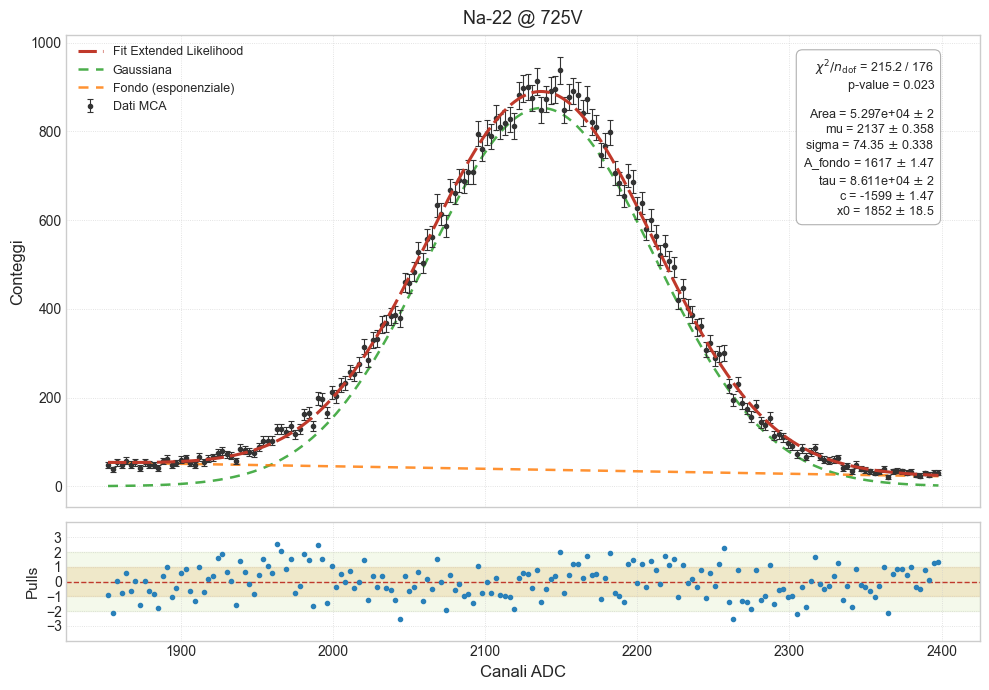

  → Risoluzione R = 0.0819+/-0.0004

  VOLTAGGIO = 750 (Taglio tra 2350 e 3100)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 750V
      Area =  5.399e+04 ± 303.5
        mu =       2784 ± 0.5023
     sigma =      97.13 ± 0.4978
   A_fondo =      21.12 ± 6.925
       tau =       1525 ± 646.7
         c =     -6.937 ± 6.969
        x0 =       2350 ± 23.5
--------------------------------------------------
Chi2 / ndof = 326.79 / 244 = 1.34
p-value     = 0.0003114


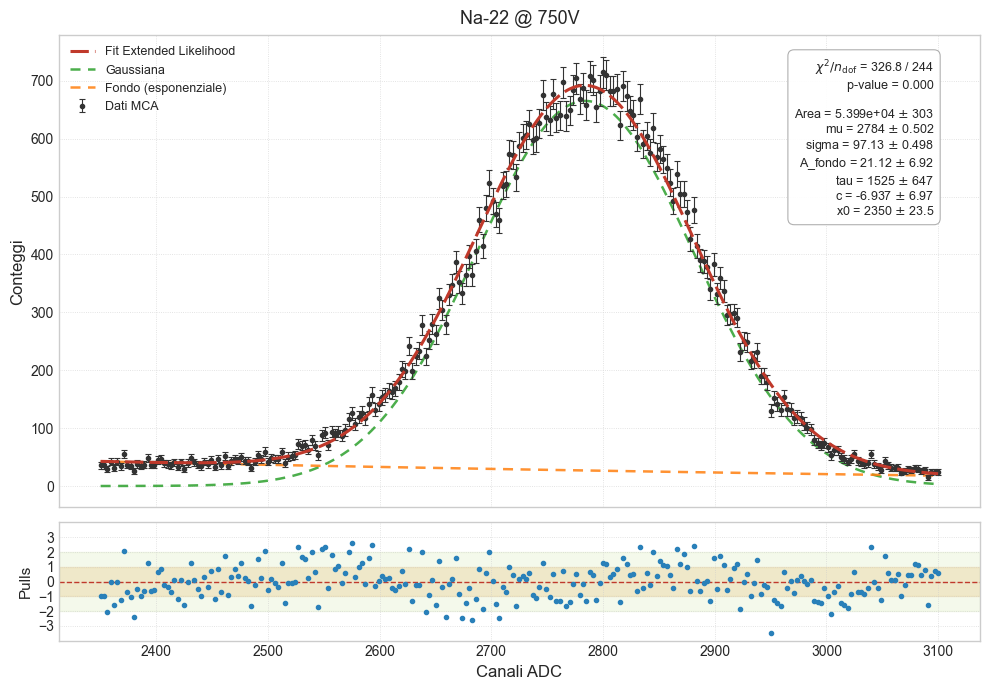

  → Risoluzione R = 0.0822+/-0.0004

  VOLTAGGIO = 775 (Taglio tra 3150 e 4000)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 775V
      Area =  5.444e+04 ± 322.3
        mu =       3603 ± 0.6755
     sigma =      126.3 ± 0.6807
   A_fondo =      30.48 ± 19.02
       tau =       3643 ± 2572
         c =     -19.79 ± 19.04
        x0 =       3151 ± 31.51
--------------------------------------------------
Chi2 / ndof = 337.51 / 277 = 1.22
p-value     = 0.007502


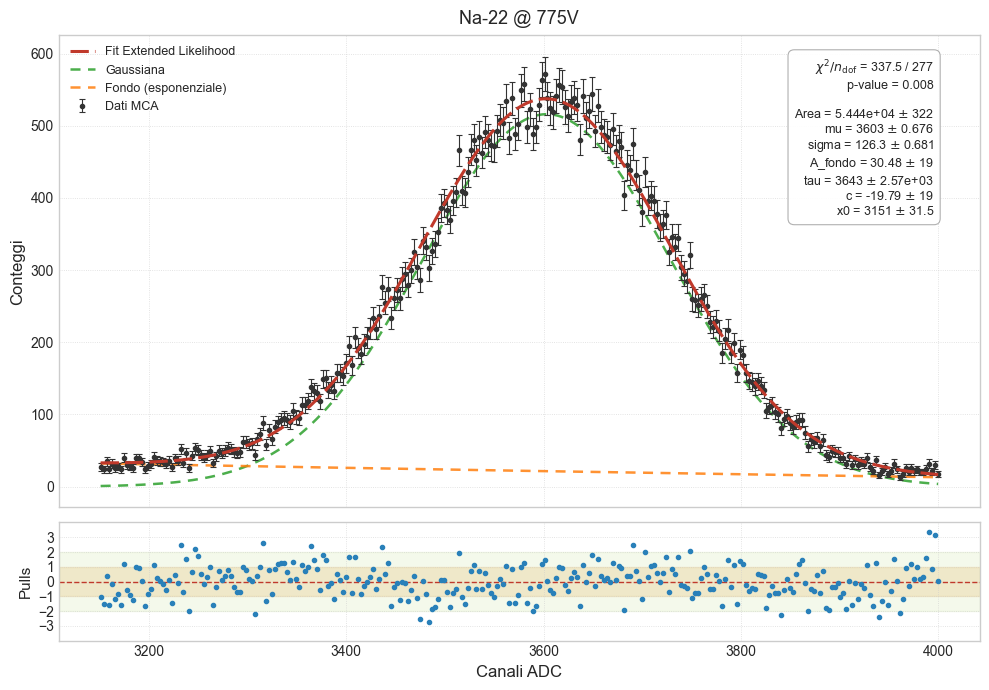

  → Risoluzione R = 0.0825+/-0.0004

  VOLTAGGIO = 800 (Taglio tra 4000 e 5100)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 800V
      Area =  5.374e+04 ± 337.3
        mu =       4613 ± 0.8623
     sigma =      160.3 ± 0.9012
   A_fondo =      15.46 ± 6.26
       tau =       2307 ± 1207
         c =     -6.918 ± 6.294
        x0 =       4000 ± 40
--------------------------------------------------
Chi2 / ndof = 391.53 / 360 = 1.09
p-value     = 0.1216


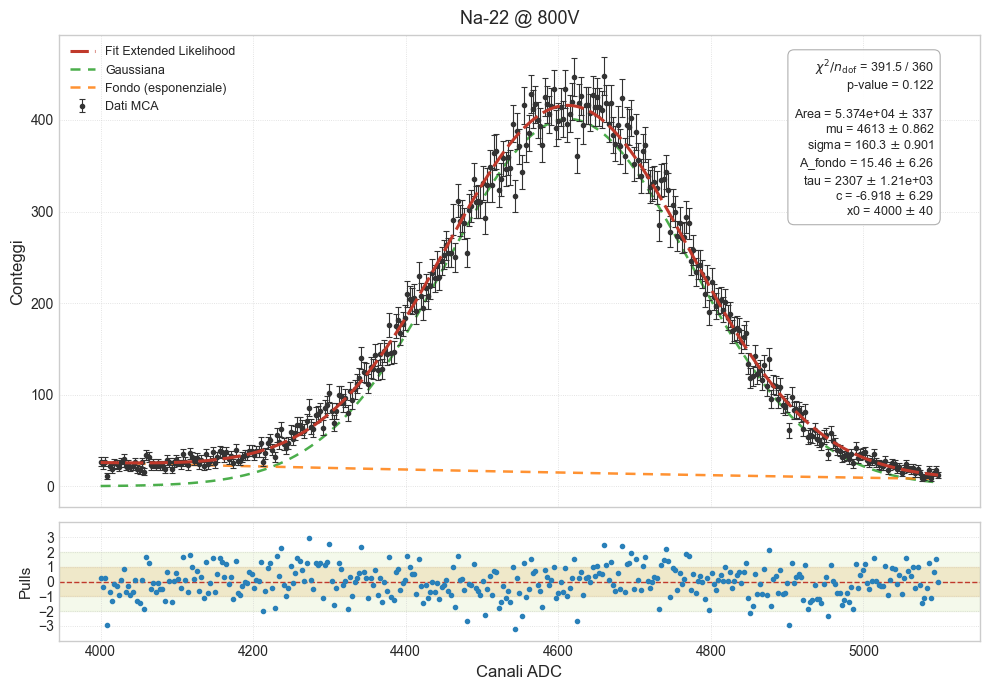

  → Risoluzione R = 0.0819+/-0.0005

  VOLTAGGIO = 825 (Taglio tra 5050 e 6300)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 825V
      Area =  5.341e+04 ± 313.5
        mu =       5855 ± 1.026
     sigma =        208 ± 1.108
   A_fondo =       1208 ± 2.205
       tau =  2.093e+05 ± 2085
         c =      -1201 ± 2.185
        x0 =       5050 ± 50.5
--------------------------------------------------
Chi2 / ndof = 445.41 / 410 = 1.09
p-value     = 0.1101


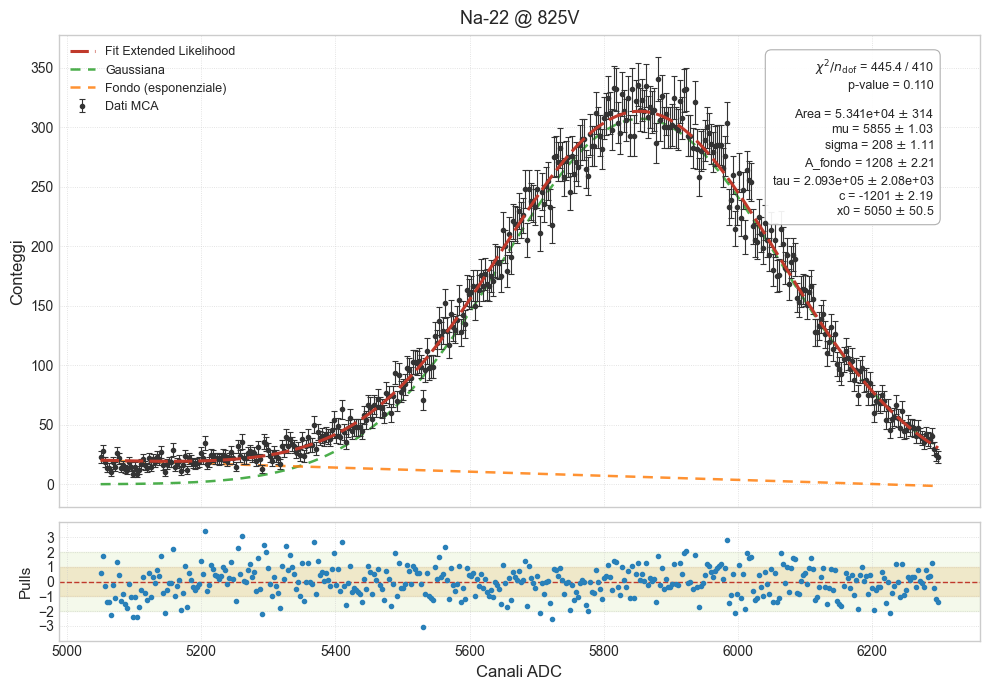

  → Risoluzione R = 0.0837+/-0.0004

  VOLTAGGIO = 850 (Taglio tra 6500 e 7900)
 RISULTATI FIT LIKELIHOOD: Na-22 @ 850V
      Area =   5.18e+04 ± 2
        mu =       7405 ± 1.121
     sigma =      248.6 ± 1.075
   A_fondo =   0.002281 ± 1.502
       tau =       6850 ± 2
         c =      5.796 ± 0.144
        x0 =       6502 ± 65.02
--------------------------------------------------
Chi2 / ndof = 499.17 / 460 = 1.09
p-value     = 0.1006


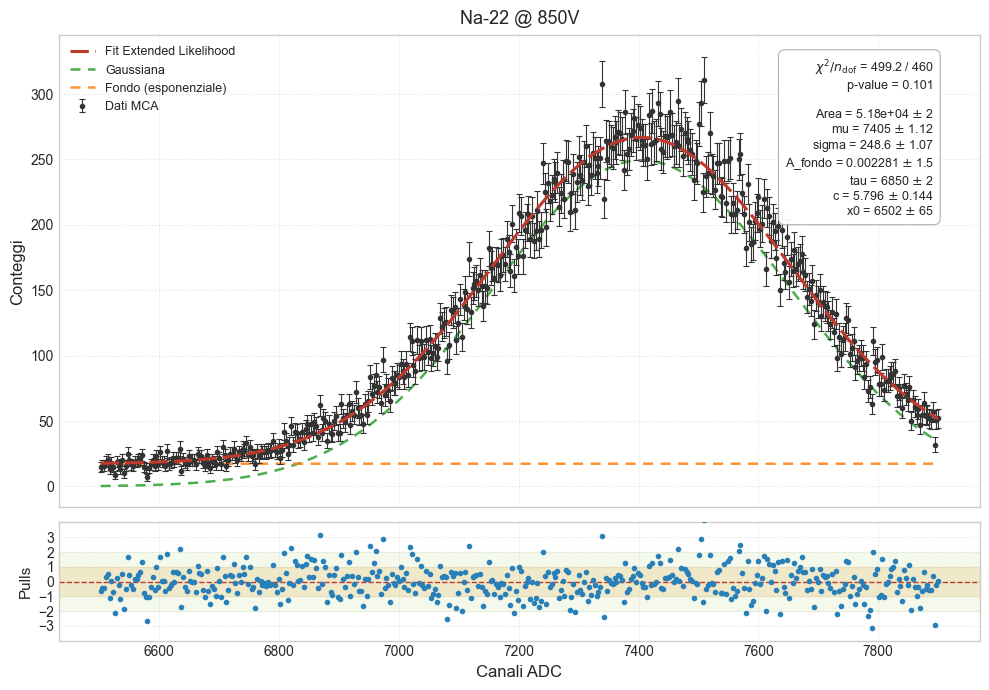

  → Risoluzione R = 0.0790+/-0.0003


In [101]:
voltaggi_volt2 = np.array([550, 600, 650, 675, 700, 725, 750, 775, 800, 825, 850])
ch_v_max_array2 = np.array([2400, 2400, 1000, 1400, 1800, 2400, 3100, 4000, 5100, 6300, 7900])
ch_v_min_array2 = np.array([1800, 1800, 700, 1000, 1400, 1850, 2350, 3150, 4000, 5050, 6500])

risultati_volt = []

for filename, volt, c_v_min, c_v_max in zip(file_volt_list2, voltaggi_volt2, ch_v_min_array2, ch_v_max_array2):
    print(f"\n{'='*60}")
    print(f"  VOLTAGGIO = {volt} (Taglio tra {c_v_min} e {c_v_max})")
    print(f"{'='*60}")
    
    percorso_completo = os.path.join(cartella_dati, filename)
    canali, conteggi = lib.estrai_spettro(percorso_completo, show_plot=False)
    canali, conteggi = lib.rebin(canali, conteggi, n=3)

    # 3. Ora c_min e c_max sono numeri singoli esatti per questo specifico file
    mask = (canali >= c_v_min) & (canali <= c_v_max)
    x_picco = canali[mask]
    y_picco = conteggi[mask]
    
    # Stime iniziali
    mu_guess = x_picco[np.argmax(y_picco)]
    area_guess = np.sum(y_picco)
    fondo_guess = np.mean(y_picco[:5])
    sigma_guess = 15
    x0_guess = x_picco[0]
    c_guess = np.mean(y_picco[-5:])
    if c_guess <= 0: c_guess = 1.0

    # 3. Stima dell'altezza dell'esponenziale 'A_fondo' (coda sinistra)
    sinistra_mean = np.mean(y_picco[:5])
    A_fondo_guess = sinistra_mean - c_guess
    if A_fondo_guess <= 0: A_fondo_guess = 10.0 # Sicurezza

    # 4. Stima di 'tau' (un terzo della finestra)
    tau_guess = (x_picco[-1] - x_picco[0]) / 3.0

    # 5. Stime del picco (mu e sigma)
    mu_guess = x_picco[np.argmax(y_picco)]
    sigma_guess = 15.0 # Per i NaI di solito è un valore iniziale eccellente

    # 6. Stima dell'Area (Totale - Area del fondo a trapezio)
    fondo_medio = (sinistra_mean + c_guess) / 2.0
    area_guess = np.sum(y_picco) - (fondo_medio * len(x_picco))
    if area_guess <= 0: area_guess = np.sum(y_picco) * 0.5
    
    # 4. Corretti i parametri per la parabola (a, b, c)
    parametri_iniziali = {
        'Area': area_guess, 
        'mu': mu_guess, 
        'sigma': sigma_guess, 
        'A_fondo': A_fondo_guess,
        'tau': tau_guess,
        'c': fondo_guess,
        'x0': x0_guess
    }
    # 5. Corretti gli assegnamenti di CDF e PDF
    fit = lib.FitLikelihoodBomberone(
        canali=x_picco,
        conteggi=y_picco,
        modello_cdf=lib.picco_esponenziale_cdf,
        modello_pdf=lib.picco_esponenziale_pdf,
        initial_params=parametri_iniziali,
        title=f"Na-22 @ {volt}V"
    )
    
    fit.perform_fit()
    fit.plot_results(componenti=[('Gaussiana', lib.funzione_gaussiana_pdf), ('Fondo (esponenziale)', lib.funzione_esponenziale_pdf)])  
    
    if fit.is_fit_valid:
        mu  = ufloat(fit.fit_result['mu'][0], fit.fit_result['mu'][1])
        sig = ufloat(fit.fit_result['sigma'][0], fit.fit_result['sigma'][1])
        
        R = 2.355 * sig / mu
        risultati_volt.append((volt, mu, sig, R))
        print(f"  → Risoluzione R = {R:.4f}")
    else:
        print(f"  ⚠️ Fit non valido per voltaggio {volt}V")


In [94]:
#Adesso sempre tenendo conto della finestra variabile
import itertools
delta = 80  #variazione della finestra
risultati_finestra = []
for filename, volt, c_minimo, c_massimo in zip(file_volt_list2, voltaggi_volt2, ch_v_min_array2, ch_v_max_array2):
    R_delta = []
    variazioni = [-delta, 0, delta]
    
    for d_minimo, d_massimo in itertools.product(variazioni, repeat=2):
        c_minimo_var = max(c_minimo + d_minimo, 0)
        c_massimo_var = c_massimo + d_massimo
        
        # Salta combinazioni degeneri
        if c_massimo_var <= c_minimo_var:
            continue
        if (c_massimo_var - c_minimo_var) < delta:
            continue
        
        percorso_completo = os.path.join(cartella_dati, filename)
        canali, conteggi = lib.estrai_spettro(percorso_completo, show_plot=False)
        canali, conteggi = lib.rebin(canali, conteggi, n=4)
        mask = (canali >= c_minimo_var) & (canali <= c_massimo_var)
        x_picco = canali[mask]
        y_picco = conteggi[mask]
        
        if len(x_picco) < 10:
            continue
        
        # Stime iniziali
        c_guess = np.mean(y_picco[-5:])
        if c_guess <= 0: c_guess = 1.0
        sinistra_mean = np.mean(y_picco[:5])
        A_fondo_guess = sinistra_mean - c_guess
        if A_fondo_guess <= 0: A_fondo_guess = 10.0
        tau_guess = (x_picco[-1] - x_picco[0]) / 3.0
        mu_guess = x_picco[np.argmax(y_picco)]
        sigma_guess = 15.0
        x0_guess = x_picco[0]
        fondo_medio = (sinistra_mean + c_guess) / 2.0
        area_guess = np.sum(y_picco) - (fondo_medio * len(x_picco))
        if area_guess <= 0: area_guess = np.sum(y_picco) * 0.5
    
        parametri = {
            'Area': area_guess, 
            'mu': mu_guess, 
            'sigma': sigma_guess, 
            'A_fondo': A_fondo_guess,
            'tau': tau_guess,
            'c': c_guess,
            'x0': x0_guess
        }
        fit_volt = lib.FitLikelihoodBomberone(
            canali = x_picco, conteggi = y_picco, 
            modello_cdf = lib.picco_esponenziale_cdf, modello_pdf = lib.picco_esponenziale_pdf,
            initial_params = parametri, title = f"Fit Variato per Volt {volt}"
        )
        fit_volt.perform_fit()
        
        if fit_volt.is_fit_valid:
            fit_volt.print_results()
            R_valore = 2.355 * fit_volt.fit_result['sigma'][0] / fit_volt.fit_result['mu'][0]
            R_delta.append(R_valore)
    
    sigma_sist = np.std(R_delta) if len(R_delta) > 1 else 0.0
    risultati_finestra.append((volt, sigma_sist))
    print(f"Voltaggio {volt}: {len(R_delta)} fit validi → σ_sist = {sigma_sist:.6f}")

 RISULTATI FIT LIKELIHOOD: Fit Variato per Volt 550
      Area =  3.986e+04 ± 239.2
        mu =       2045 ± 0.4173
     sigma =      73.86 ± 0.4037
   A_fondo =       1591 ± 2.777
       tau =  1.275e+05 ± 1688
         c =      -1577 ± 2.796
        x0 =       1722 ± 17.21
--------------------------------------------------
Chi2 / ndof = 215.71 / 143 = 1.51
p-value     = 8.178e-05
 RISULTATI FIT LIKELIHOOD: Fit Variato per Volt 550
      Area =  3.986e+04 ± 239.2
        mu =       2045 ± 0.4173
     sigma =      73.86 ± 0.4037
   A_fondo =       1591 ± 2.777
       tau =  1.275e+05 ± 1688
         c =      -1577 ± 2.796
        x0 =       1722 ± 17.21
--------------------------------------------------
Chi2 / ndof = 215.71 / 143 = 1.51
p-value     = 8.178e-05
 RISULTATI FIT LIKELIHOOD: Fit Variato per Volt 550
      Area =  3.983e+04 ± 270.5
        mu =       2045 ± 0.4312
     sigma =      73.68 ± 0.4249
   A_fondo =      12.52 ± 6.379
       tau =      806.4 ± 652.4
         c =  

In [95]:
#Calcolo di R tenendo conto degli errori delle finestre

risultati_validi_volt = [(volt, mu, sig, R) for volt, mu, sig, R in risultati_volt if R is not None]
R_nominali_volt = np.array([r[3].nominal_value for r in risultati_validi_volt])
R_errori_volt   = np.array([r[3].std_dev for r in risultati_validi_volt])

# Media pesata: w_i = 1/sigma_i^2
pesi = 1.0 / R_errori_volt**2
R_media_volt = np.sum(pesi * R_nominali_volt) / np.sum(pesi)
R_media_err_volt = 1.0 / np.sqrt(np.sum(pesi))

print(f"R media pesata = {R_media_volt:.6f} ± {R_media_err_volt:.6f}")
print(f"R media pesata = {R_media_volt*100:.3f}% ± {R_media_err_volt*100:.3f}%")

R_tot_nominali_volt = np.array([r[3].nominal_value for r in risultati_validi_volt])
diz_sist_volt = dict(risultati_finestra)
R_tot_errori_volt = np.array([
    np.sqrt(r[3].std_dev**2 + diz_sist_volt[r[0]]**2)
    for i, r in enumerate(risultati_validi_volt)
])

pesi_tot_volt = 1.0 / R_tot_errori_volt**2
R_media_tot_volt = np.sum(pesi_tot_volt * R_tot_nominali_volt) / np.sum(pesi_tot_volt)
R_media_tot_err_volt = 1.0 / np.sqrt(np.sum(pesi_tot_volt))

print(f"R media pesata (con sist) = {R_media_tot_volt:.6f} ± {R_media_tot_err_volt:.6f}")
print(f"R media pesata (con sist) = {R_media_tot_volt*100:.3f}% ± {R_media_tot_err_volt*100:.3f}%")
'''
print("\n" + "="*60)
print("  TEST DI COMPATIBILITÀ CON ERRORE SISTEMATICO")
print("="*60)

for i, (volt, mu, sig, R) in enumerate(risultati_validi_volt):
    sigma_tot_volt = R_tot_errori_volt[i]
    print(f"\n  [σ_stat={R.std_dev:.5f}, σ_sist={diz_sist_volt[volt]:.5f}, σ_tot={sigma_tot_volt:.5f}]")
    lib.test_compatibilita(
        R.nominal_value, R_media_tot_volt,
        sigma_tot_volt, R_media_tot_err_volt,
        val1_name=f"R(volt={volt})",
        val2_name="R_media"
    )'''

R media pesata = 0.082454 ± 0.000133
R media pesata = 8.245% ± 0.013%
R media pesata (con sist) = 0.082871 ± 0.000259
R media pesata (con sist) = 8.287% ± 0.026%


'\nprint("\n" + "="*60)\nprint("  TEST DI COMPATIBILITÀ CON ERRORE SISTEMATICO")\nprint("="*60)\n\nfor i, (volt, mu, sig, R) in enumerate(risultati_validi_volt):\n    sigma_tot_volt = R_tot_errori_volt[i]\n    print(f"\n  [σ_stat={R.std_dev:.5f}, σ_sist={diz_sist_volt[volt]:.5f}, σ_tot={sigma_tot_volt:.5f}]")\n    lib.test_compatibilita(\n        R.nominal_value, R_media_tot_volt,\n        sigma_tot_volt, R_media_tot_err_volt,\n        val1_name=f"R(volt={volt})",\n        val2_name="R_media"\n    )'

C:\Users\Andrea\AppData\Local\Temp\ipykernel_17688\1762299395.py:28: UserWarning: Glyph 8853 (\N{CIRCLED PLUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Andrea\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8853 (\N{CIRCLED PLUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


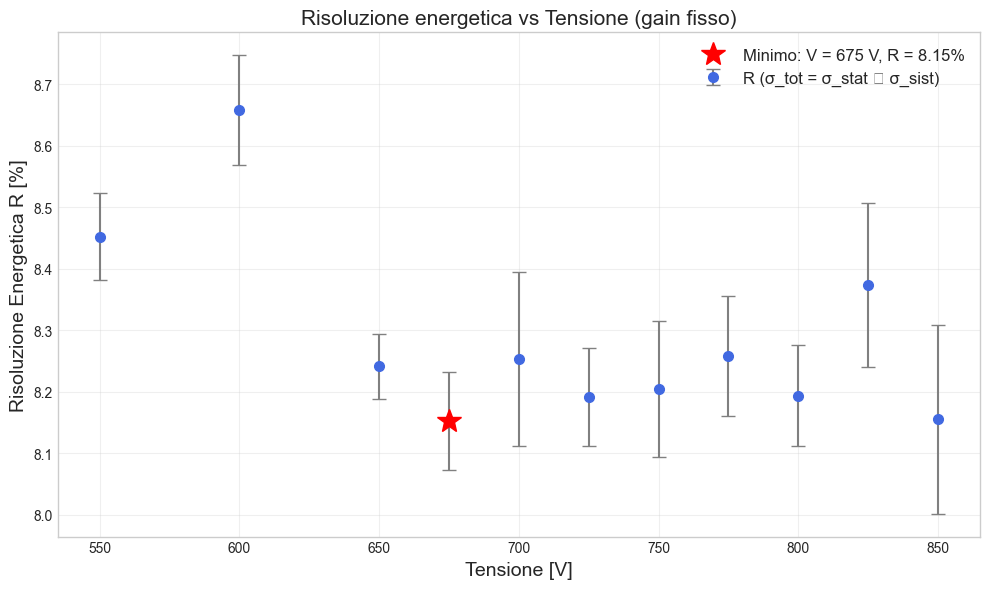


V_ottimale = 675 V
R_minima = 8.152% ± 0.080%


In [96]:
#Adesso dovrei o fare un grafico per R in funzione di V e nel caso interpolare R con una parabola ad esempio così da trovare il minimo
risultati_validi_volt = [(volt, mu, sig, R) for volt, mu, sig, R in risultati_volt if R is not None]
R_nominali_volt = np.array([r[3].nominal_value for r in risultati_validi_volt])
diz_sist_volt = dict(risultati_finestra)
R_tot_errori_volt = np.array([
    np.sqrt(r[3].std_dev**2 + diz_sist_volt[r[0]]**2)
    for i, r in enumerate(risultati_validi_volt)
])  #Questo anche con errori dati dal variare della finestra
V_plot = np.array([r[0] for r in risultati_validi_volt])
R_tot_nominali_volt = np.array([r[3].nominal_value for r in risultati_validi_volt])


fig, ax = plt.subplots(figsize=(10, 6))
# Plot con errori totali (stat ⊕ sist)
ax.errorbar(V_plot, R_tot_nominali_volt * 100, yerr=R_tot_errori_volt * 100,
            fmt='o', capsize=5, markersize=7, color='royalblue',
            ecolor='gray', elinewidth=1.5, label='R (σ_tot = σ_stat ⊕ σ_sist)')
# Evidenzia il minimo
idx_min = np.argmin(R_tot_nominali_volt)
ax.plot(V_plot[idx_min], R_tot_nominali_volt[idx_min] * 100, 
        '*', markersize=18, color='red', zorder=5,
        label=f'Minimo: V = {V_plot[idx_min]:.0f} V, R = {R_tot_nominali_volt[idx_min]*100:.2f}%')
ax.set_xlabel('Tensione [V]', fontsize=14)
ax.set_ylabel('Risoluzione Energetica R [%]', fontsize=14)
ax.set_title('Risoluzione energetica vs Tensione (gain fisso)', fontsize=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\nV_ottimale = {V_plot[idx_min]:.0f} V")
print(f"R_minima = {R_tot_nominali_volt[idx_min]*100:.3f}% ± {R_tot_errori_volt[idx_min]*100:.3f}%")

--- Esecuzione Fit con Metodo: Scipy ---
Fit completato.

--- Risultati del Fit (Scipy) ---
Fit Valido: Sì

Parametri Ottimizzati:
  m = -1.268e-05 ± 3.5e-06
  q = 0.09144 ± 0.0024

Statistiche del Fit:
  Chi-quadro (χ²): 16.3925
  Gradi di libertà (DoF): 7
  Chi-quadro Ridotto (χ²/DoF): 2.3418
  p-value: 0.0218


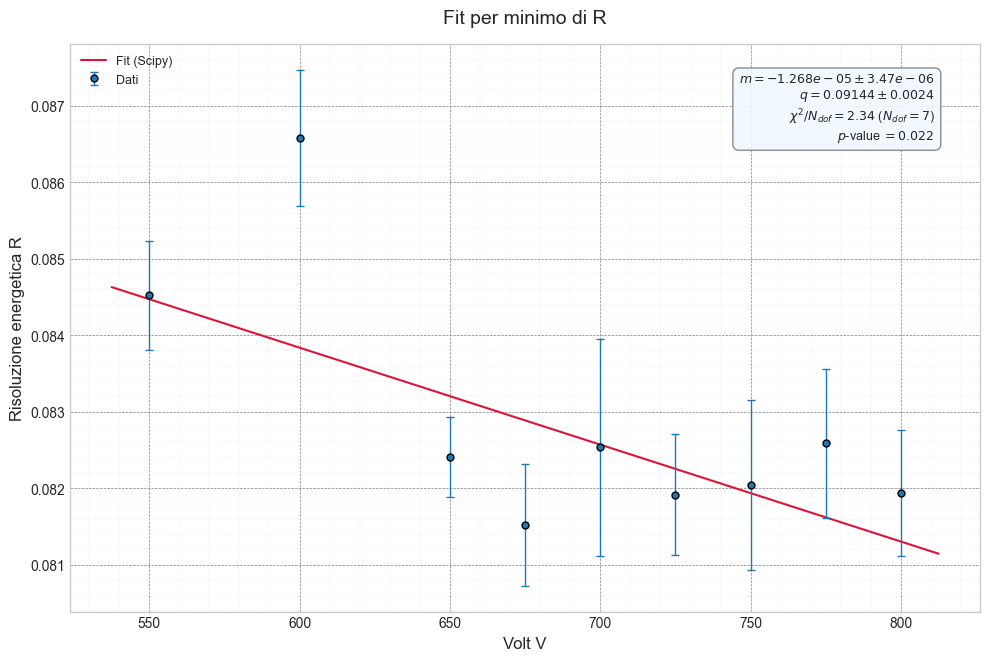

In [97]:
#Adesso fit parabolico attorno al minimo
from uncertainties import correlated_values

# Estraiamo i primi 4 valori (indice 0, 1, 2, 3) 

dizionario_sist = dict(risultati_finestra)
R_tot_nominali_volt = np.array([r[3].nominal_value for r in risultati_validi_volt])
R_tot_errori_volt = np.array([
    np.sqrt(r[3].std_dev**2 + dizionario_sist[r[0]]**2)
    for r in risultati_validi_volt
])
V_plot2 = V_plot


def parabola(x, a, b, c):
    return a*(x**2) + b*x + c

def retta(x, m, q):
    return m*x + q

data_minimo_R2 = {'x': V_plot2[0:9], 'y': R_nominali_volt[0:9], 'sigma_y': R_tot_errori_volt[0:9]}
data_minimo_R = {'x': V_plot2, 'y': R_nominali_volt, 'sigma_y': R_tot_errori_volt}
parametri_minimo_R_parabola = {'a':1e-6, 'b':0.0, 'c': 0.05}
parametri_minimo_R_retta = {'m':1e-6, 'q':0.05}


fit_minimo_R = lib.FitBomberone2(
    model_func = retta, data_arrays=data_minimo_R2, initial_params = parametri_minimo_R_retta,
    fit_method='Scipy',   
    xlabel='Volt V', ylabel='Risoluzione energetica R', title='Fit per minimo di R'
    )
fit_minimo_R.perform_fit()

'''
cov = fit_minimo_R.scipy_pcov
#valori = [fit_minimo_R.fit_result['a'][0], fit_minimo_R.fit_result['b'][0], fit_minimo_R.fit_result['c'][0]]
valori_retta = [fit_minimo_R.fit_result['a'][0], fit_minimo_R.fit_result['b'][0]]
#a, b, c = correlated_values(valori, cov)
a, b = correlated_values(valori, cov)'''

fit_minimo_R.print_results()
fit_minimo_R.plot_results(log_scale_y=False, log_scale_x=False, info_box_pos='upper right')

Togliendo i primi due valori

--- Esecuzione Fit con Metodo: Scipy ---
Fit completato.

--- Risultati del Fit (Scipy) ---
Fit Valido: Sì

Parametri Ottimizzati:
  m = -9.663e-07 ± 5.5e-06
  q = 0.08282 ± 0.0039

Statistiche del Fit:
  Chi-quadro (χ²): 1.2762
  Gradi di libertà (DoF): 5
  Chi-quadro Ridotto (χ²/DoF): 0.2552
  p-value: 0.9374


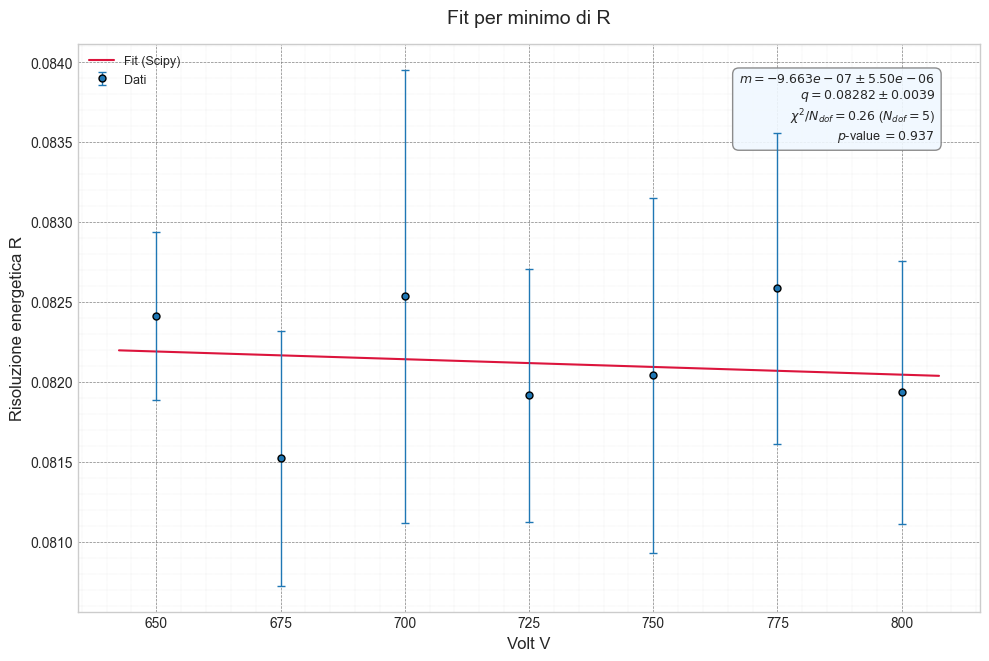

In [98]:
#Adesso fit parabolico attorno al minimo
from uncertainties import correlated_values

# Estraiamo i primi 4 valori (indice 0, 1, 2, 3) 

dizionario_sist = dict(risultati_finestra)
R_tot_nominali_volt = np.array([r[3].nominal_value for r in risultati_validi_volt])
R_tot_errori_volt = np.array([
    np.sqrt(r[3].std_dev**2 + dizionario_sist[r[0]]**2)
    for r in risultati_validi_volt
])
V_plot2 = V_plot


def parabola(x, a, b, c):
    return a*(x**2) + b*x + c

def retta(x, m, q):
    return m*x + q

data_minimo_R2 = {'x': V_plot2[2:9], 'y': R_nominali_volt[2:9], 'sigma_y': R_tot_errori_volt[2:9]}
data_minimo_R = {'x': V_plot2, 'y': R_nominali_volt, 'sigma_y': R_tot_errori_volt}
parametri_minimo_R_parabola = {'a':1e-6, 'b':0.0, 'c': 0.05}
parametri_minimo_R_retta = {'m':1e-6, 'q':0.05}


fit_minimo_R = lib.FitBomberone2(
    model_func = retta, data_arrays=data_minimo_R2, initial_params = parametri_minimo_R_retta,
    fit_method='Scipy',   
    xlabel='Volt V', ylabel='Risoluzione energetica R', title='Fit per minimo di R'
    )
fit_minimo_R.perform_fit()

'''
cov = fit_minimo_R.scipy_pcov
#valori = [fit_minimo_R.fit_result['a'][0], fit_minimo_R.fit_result['b'][0], fit_minimo_R.fit_result['c'][0]]
valori_retta = [fit_minimo_R.fit_result['a'][0], fit_minimo_R.fit_result['b'][0]]
#a, b, c = correlated_values(valori, cov)
a, b = correlated_values(valori, cov)'''

fit_minimo_R.print_results()
fit_minimo_R.plot_results(log_scale_y=False, log_scale_x=False, info_box_pos='upper right')

Ho che il coefficiente angolare è compatibile con 0, quindi in un intorno di tensione ragionevole ho che  
la risoluzione è minima (cioè ottimale) per 
ogni valore di tensione